In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# =====================================================================
# 0. Carga (igual que antes)
# =====================================================================
ruta = "precipitacion_valle_cauca.csv"
df = pd.read_csv(ruta, parse_dates=['FechaObservacion'])
df['ValorObservado'] = pd.to_numeric(df['ValorObservado'], errors='coerce')
df['Fecha'] = df['FechaObservacion'].dt.date
df['Año']   = df['FechaObservacion'].dt.year
df['Mes']   = df['FechaObservacion'].dt.month
df['Dia']   = df['FechaObservacion'].dt.day

C:\Users\ASIS-INFORMATICA\AppData\Local\Temp\ipykernel_21068\2052735901.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(ruta, parse_dates=['FechaObservacion'])


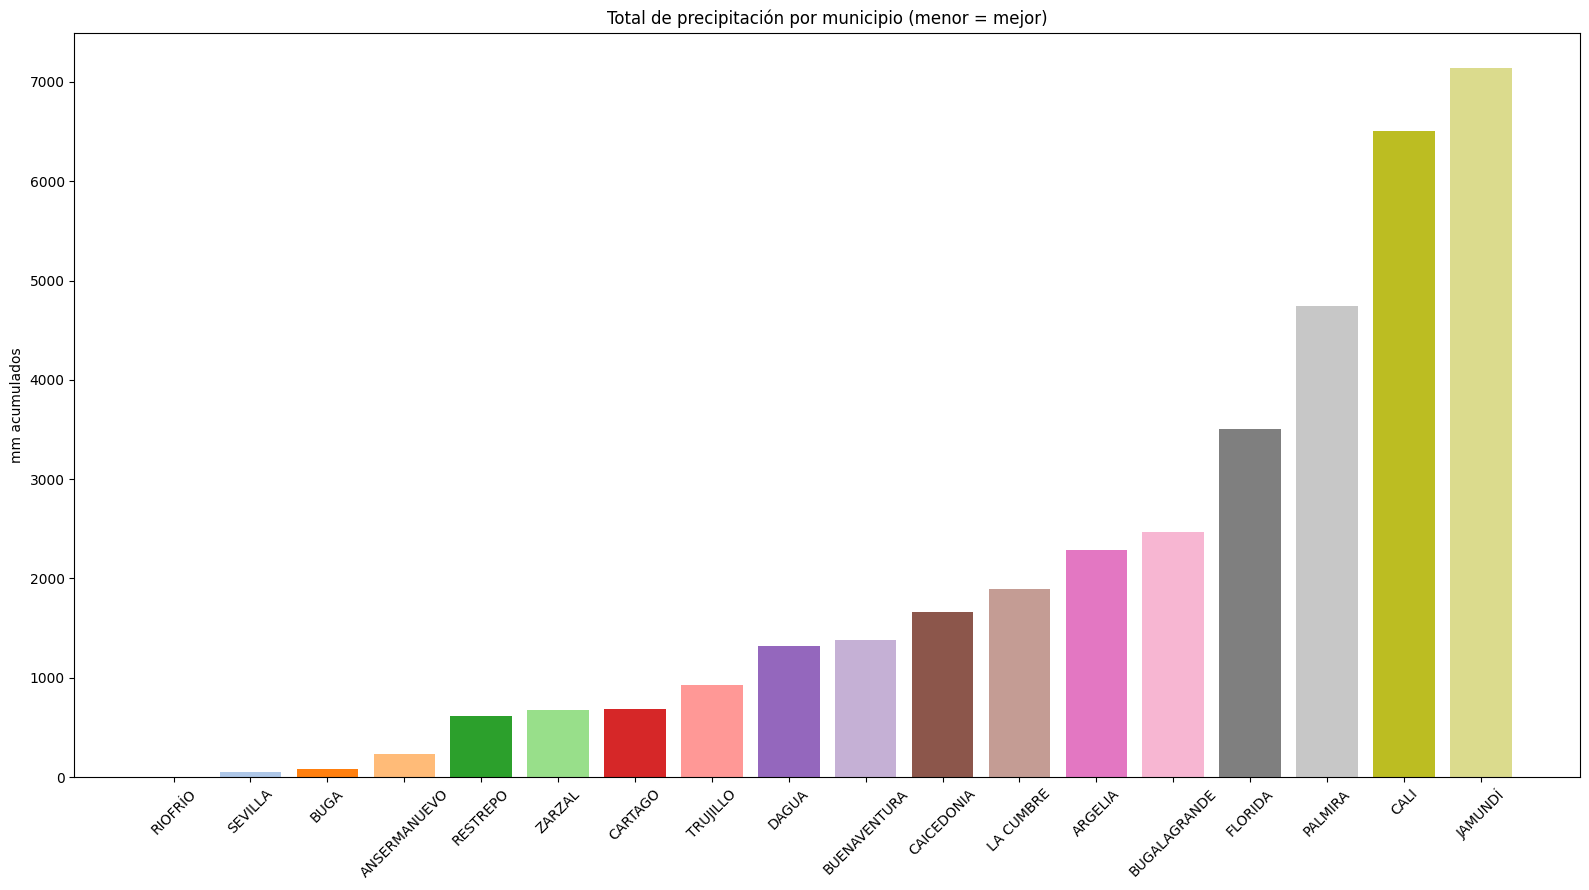

In [3]:
# ------------------------------
# 1. Total acumulado por municipio
# ------------------------------
totales = df.groupby('Municipio')['ValorObservado'].sum().sort_values()
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
ax.bar(totales.index, totales.values, color=plt.get_cmap('tab20').colors)
ax.set_ylabel('mm acumulados')
ax.set_title('Total de precipitación por municipio (menor = mejor)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


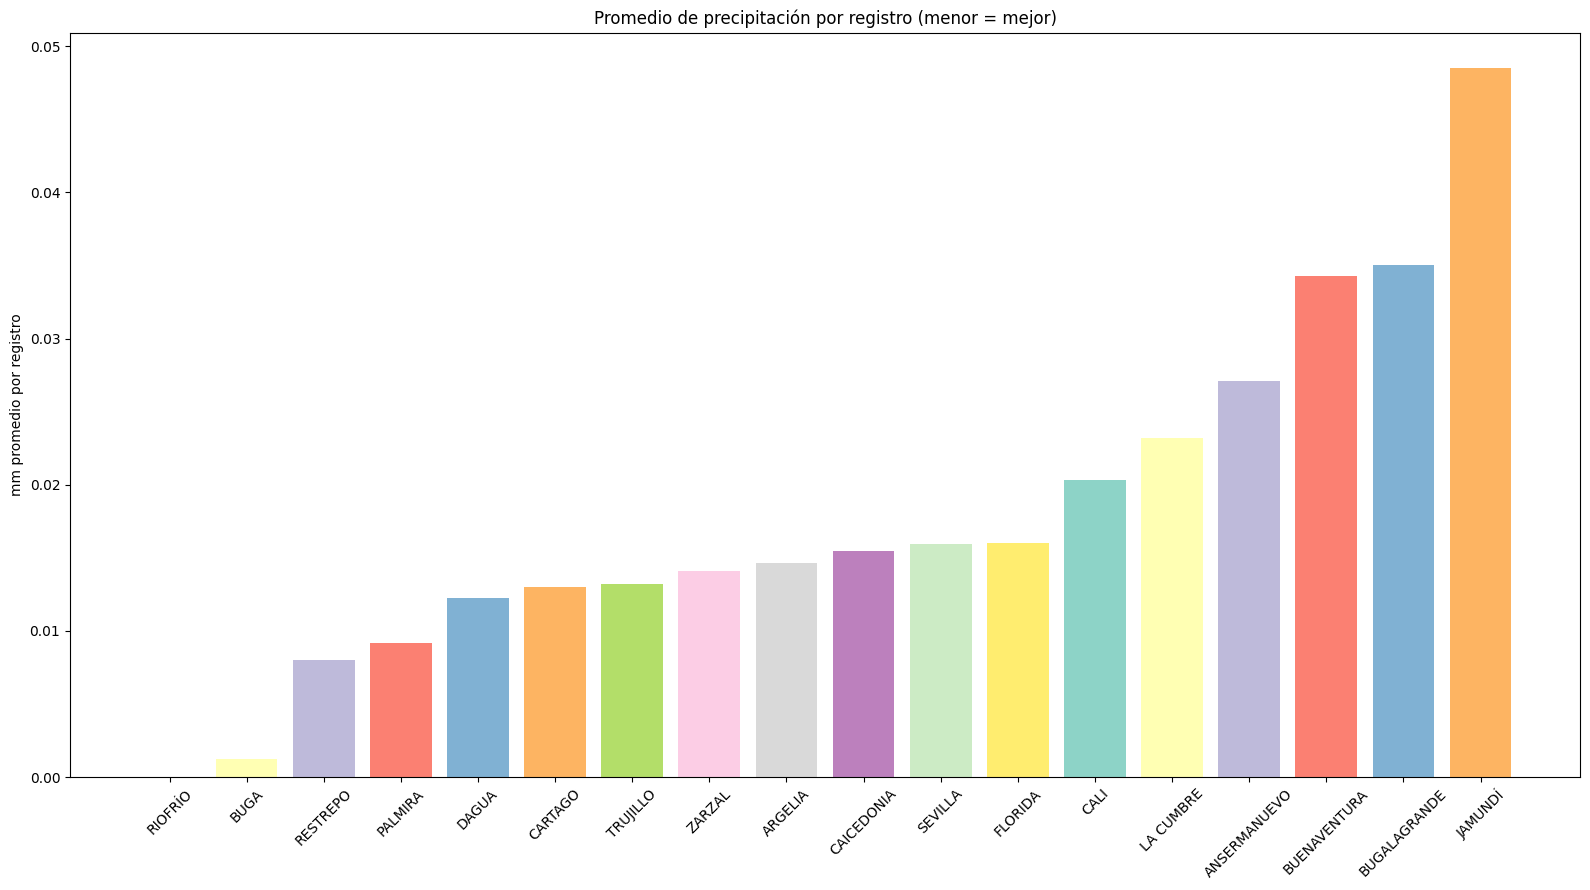

In [4]:
# ------------------------------
# 2. Promedio por registro
# ------------------------------
medias = df.groupby('Municipio')['ValorObservado'].mean().sort_values()
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
ax.bar(medias.index, medias.values, color=plt.get_cmap('Set3').colors)
ax.set_ylabel('mm promedio por registro')
ax.set_title('Promedio de precipitación por registro (menor = mejor)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ASIS-INFORMATICA\AppData\Local\Temp\ipykernel_21068\3688757183.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dias_secos = dias_mpio.groupby('Municipio').apply(lambda x: (x['ValorObservado']==0).mean()*100)


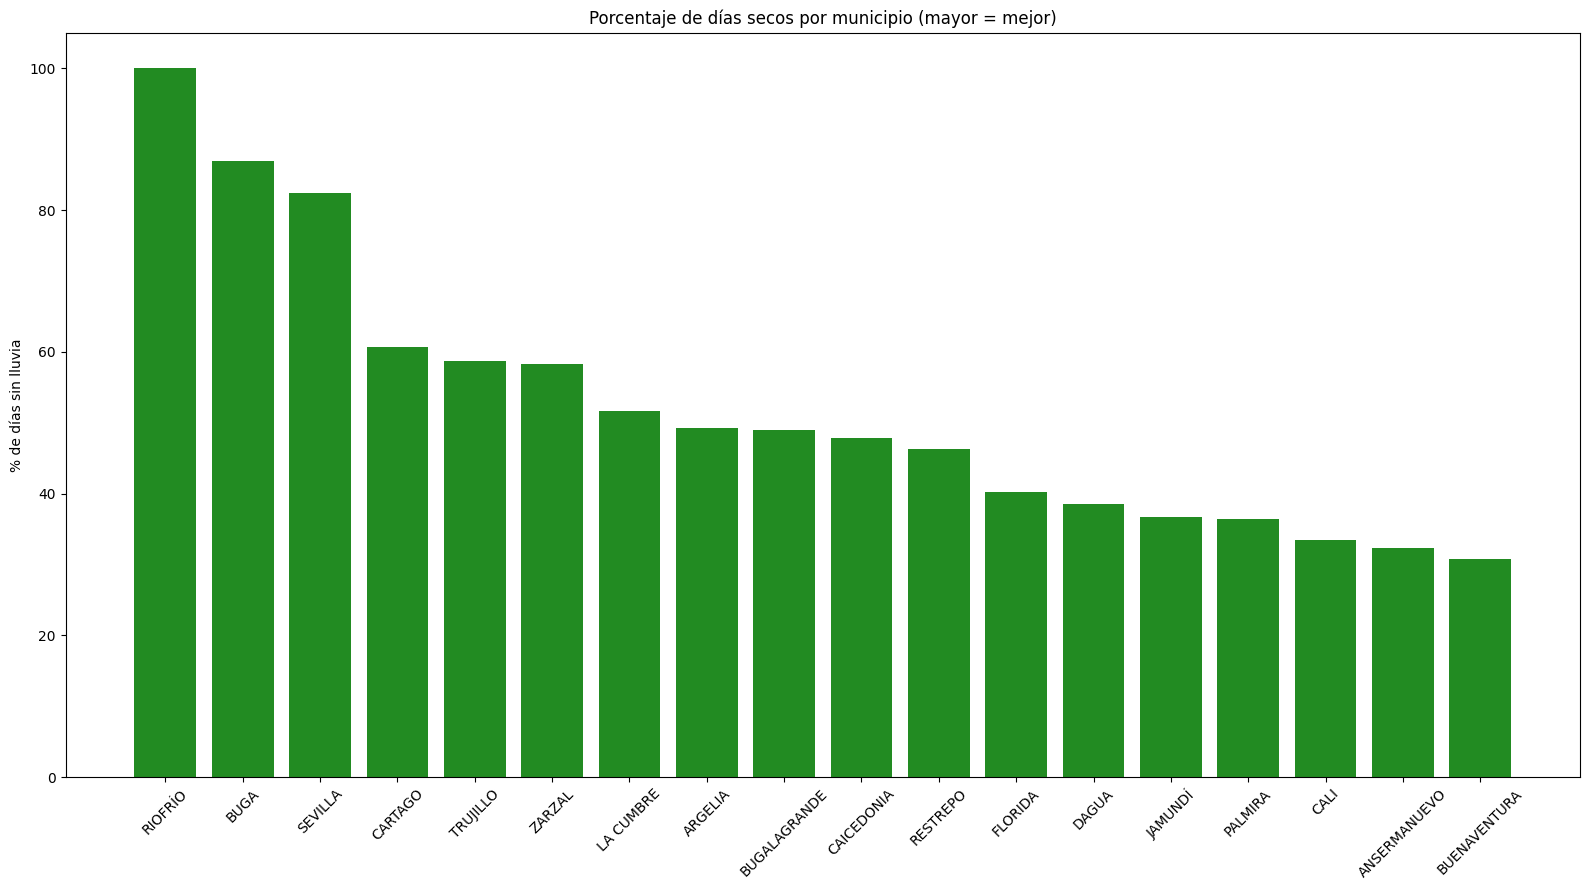

In [5]:
# ------------------------------
# 3. % de días secos
# ------------------------------
dias_mpio = df.groupby(['Municipio','Fecha'])['ValorObservado'].sum().reset_index()
dias_secos = dias_mpio.groupby('Municipio').apply(lambda x: (x['ValorObservado']==0).mean()*100)
dias_secos = dias_secos.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
ax.bar(dias_secos.index, dias_secos.values, color='forestgreen')
ax.set_ylabel('% de días sin lluvia')
ax.set_title('Porcentaje de días secos por municipio (mayor = mejor)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


C:\Users\ASIS-INFORMATICA\AppData\Local\Temp\ipykernel_21068\290657528.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_box, labels=dias_secos.index, showfliers=False, vert=True)


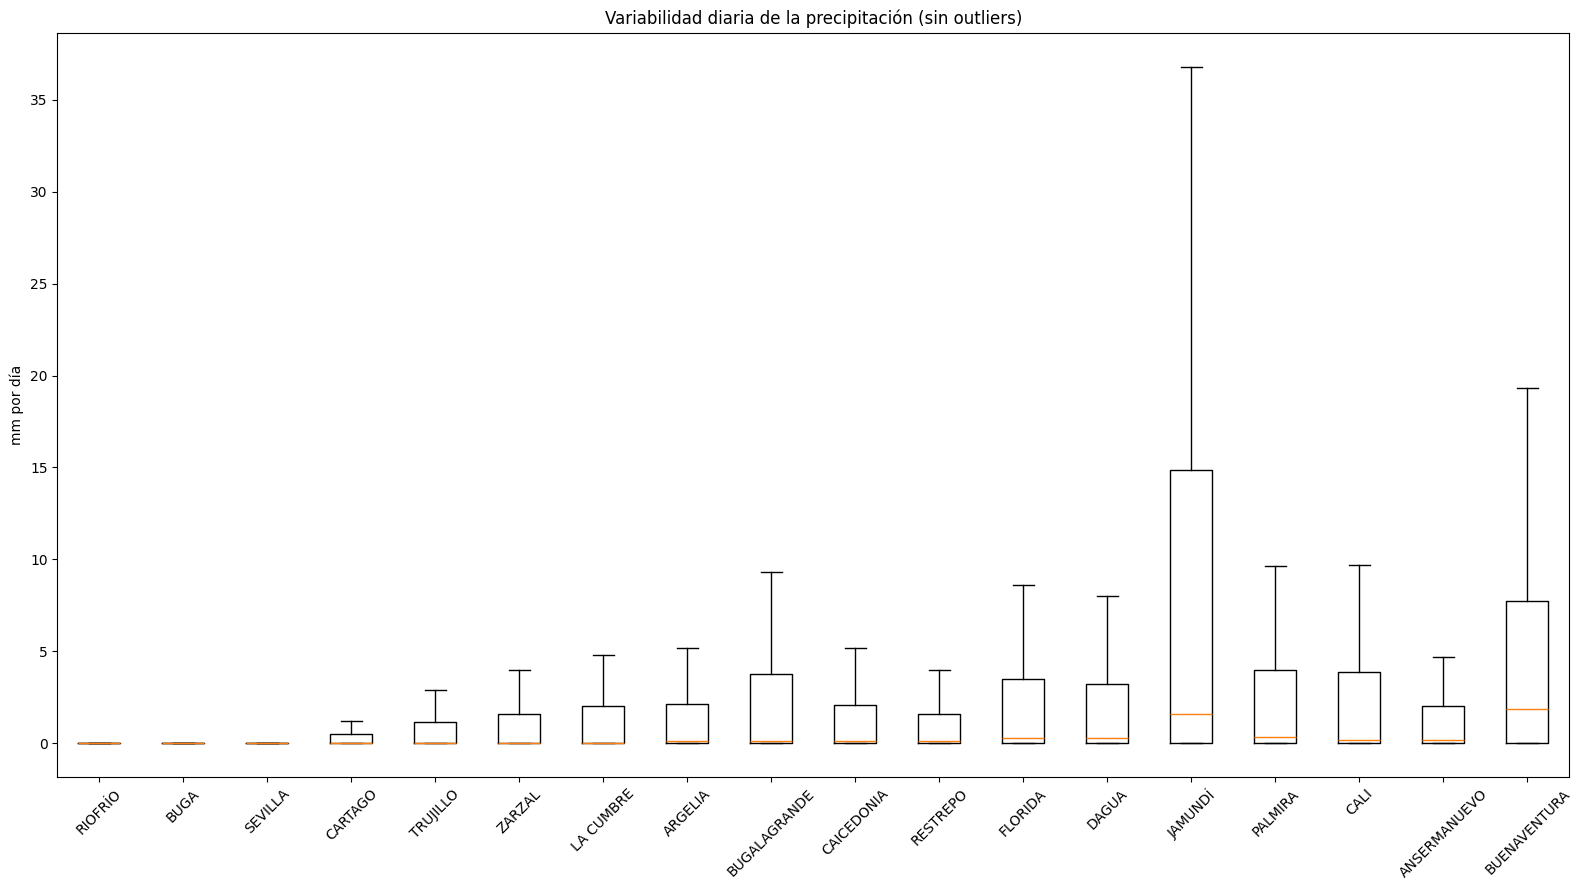

In [6]:
# ------------------------------
# 4. Boxplot de variabilidad diaria
# ------------------------------
datos_box = [dias_mpio[dias_mpio['Municipio']==m]['ValorObservado'] for m in dias_secos.index]
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
ax.boxplot(datos_box, labels=dias_secos.index, showfliers=False, vert=True)
ax.set_ylabel('mm por día')
ax.set_title('Variabilidad diaria de la precipitación (sin outliers)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


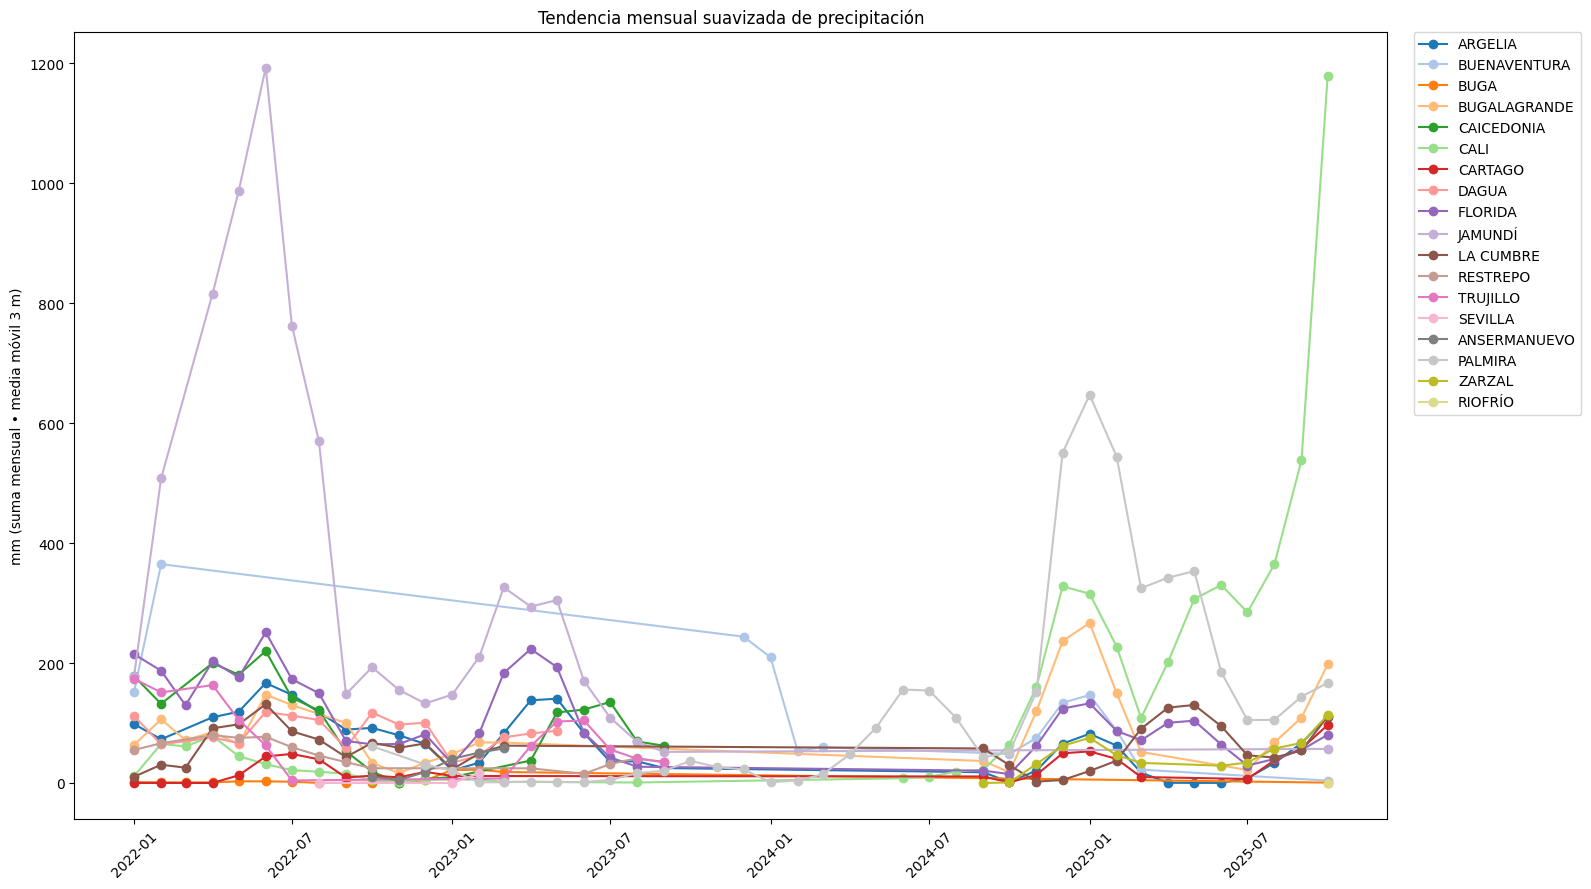

In [7]:
# ------------------------------
# 5. Tendencia mensual suavizada
# ------------------------------
mensual = df.groupby(['Año','Mes','Municipio'])['ValorObservado'].sum().reset_index()
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
cmap = plt.get_cmap('tab20')
municipios = mensual['Municipio'].unique()
colors = [cmap(i % 20) for i in range(len(municipios))]

for idx, m in enumerate(municipios):
    serie = mensual[mensual['Municipio']==m]
    fechas = pd.to_datetime(dict(year=serie['Año'], month=serie['Mes'], day=1))
    ax.plot(fechas,
            serie['ValorObservado'].rolling(3, min_periods=1).mean(),
            marker='o',
            label=m,
            color=colors[idx])
ax.set_ylabel('mm (suma mensual • media móvil 3 m)')
ax.set_title('Tendencia mensual suavizada de precipitación')
plt.xticks(rotation=45)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

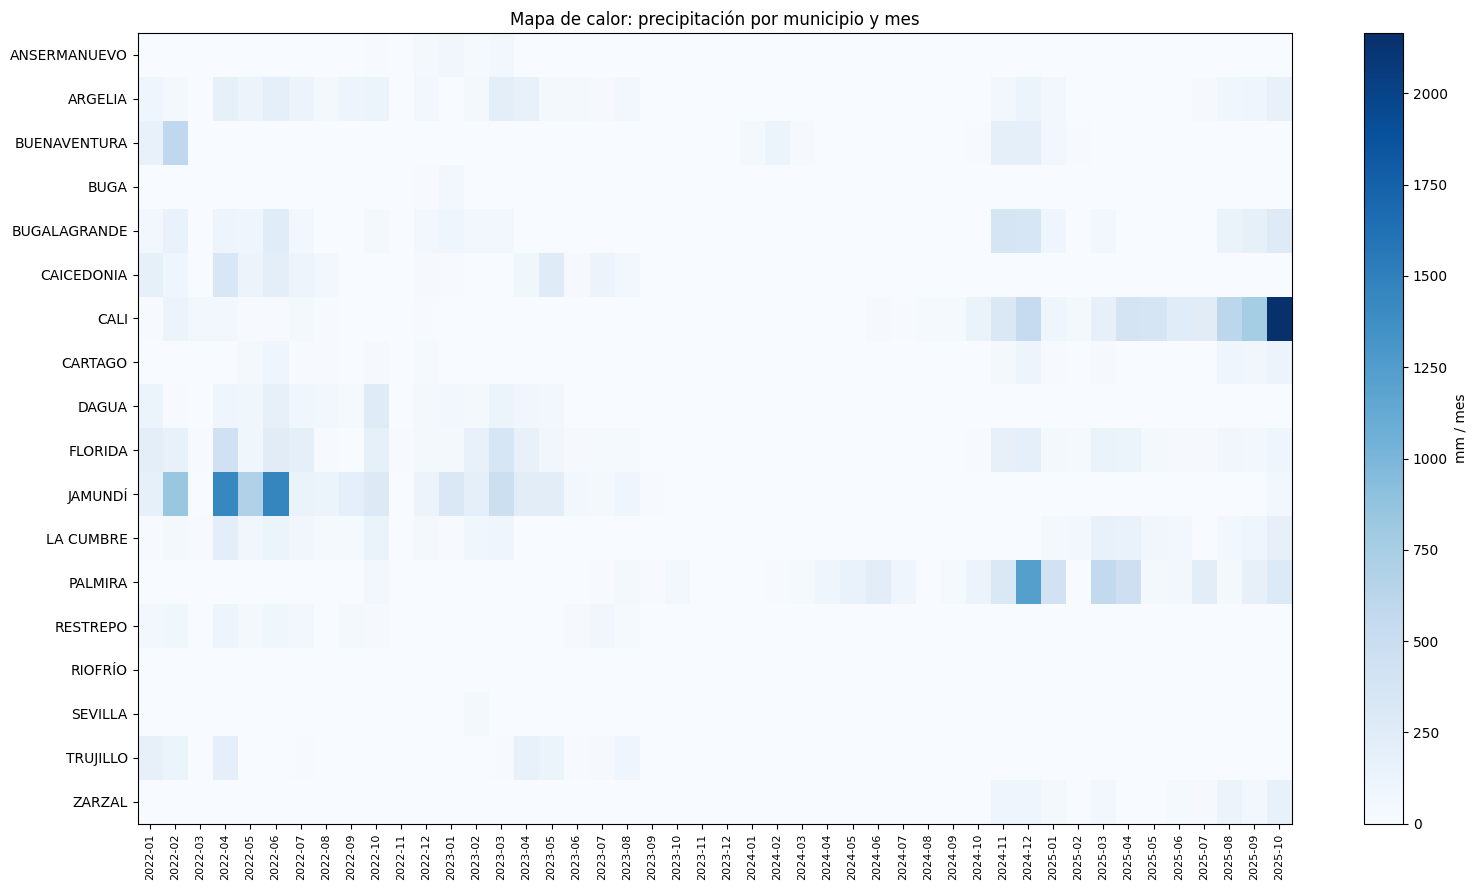

In [8]:
# ------------------------------
# 6. Heatmap Año-Mes-Municipio
# ------------------------------
pivot = mensual.pivot_table(index=['Año','Mes'],
                            columns='Municipio',
                            values='ValorObservado',
                            fill_value=0)
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
im = ax.imshow(pivot.T, aspect='auto', cmap='Blues')
ax.set_yticks(range(len(pivot.columns)))
ax.set_yticklabels(pivot.columns)
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels([f"{a}-{m:02d}" for a,m in pivot.index], rotation=90, fontsize=8)
fig.colorbar(im, ax=ax, label='mm / mes')
ax.set_title('Mapa de calor: precipitación por municipio y mes')
plt.tight_layout()
plt.show()


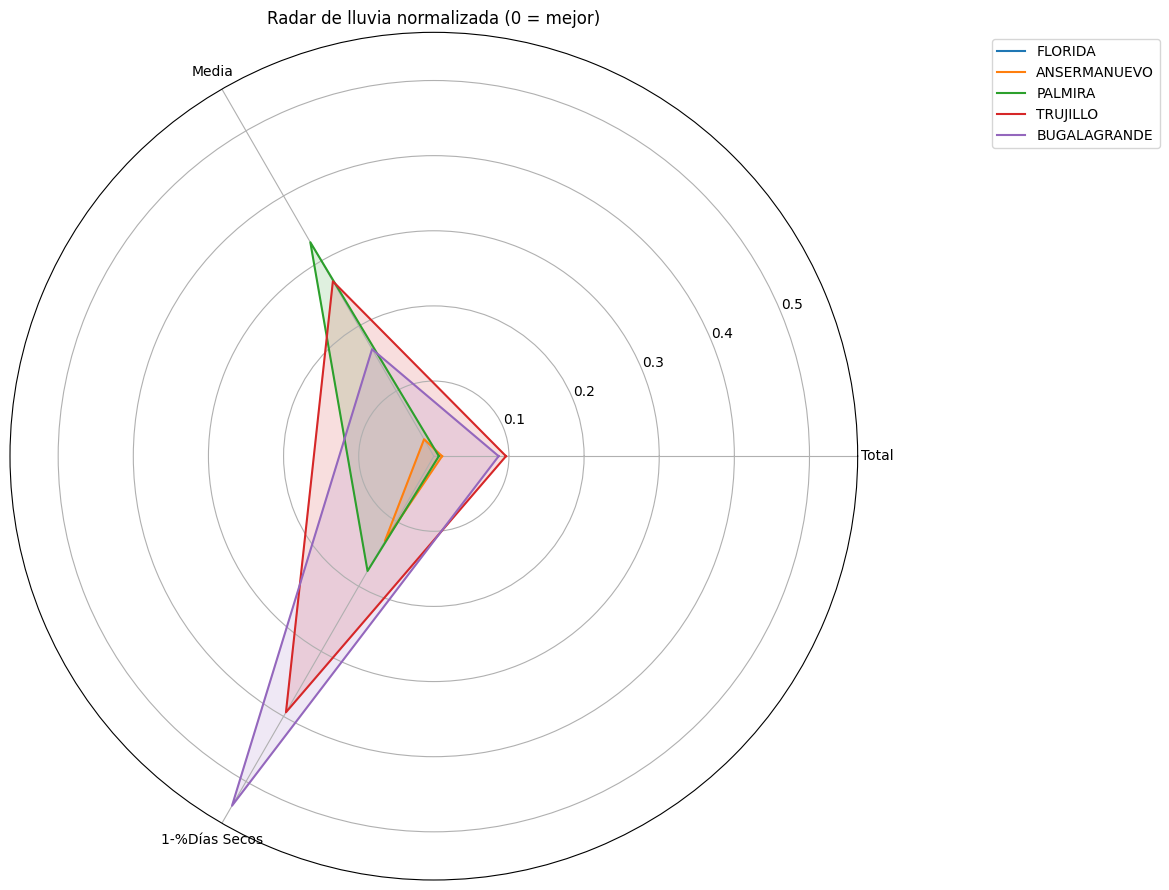

In [9]:
# ------------------------------
# 7. Radar (spider) plot
# ------------------------------
df_rank = pd.DataFrame({
    'Municipio'          : totales.index,
    'Total_norm'         : (totales - totales.min()) / (totales.max() - totales.min()),
    'Media_norm'         : (medias - medias.min()) / (medias.max() - medias.min()),
    'DiasSecos_norm_inv' : 1 - (dias_secos/100)          # menor es mejor
}).set_index('Municipio')
df_rank['Score'] = df_rank.mean(axis=1)
df_rank = df_rank.sort_values('Score')
top5 = df_rank.head(5)

angles = [n / 3 * 2*pi for n in range(3)] + [0]
labels_radar = ['Total', 'Media', '1-%Días Secos']

fig = plt.figure(figsize=(16, 9), dpi=100)
ax = fig.add_subplot(111, polar=True)
cmap_r = plt.get_cmap('tab10')

for idx, m in enumerate(top5.index):
    valores = top5.loc[m, ['Total_norm','Media_norm','DiasSecos_norm_inv']].tolist()
    valores += valores[:1]
    ax.plot(angles, valores, label=m, color=cmap_r(idx))
    ax.fill(angles, valores, alpha=0.15, color=cmap_r(idx))

ax.set_thetagrids([0, 120, 240], labels_radar)
ax.set_title('Radar de lluvia normalizada (0 = mejor)')
ax.legend(bbox_to_anchor=(1.15, 1), loc='upper left')
plt.tight_layout()
plt.show()

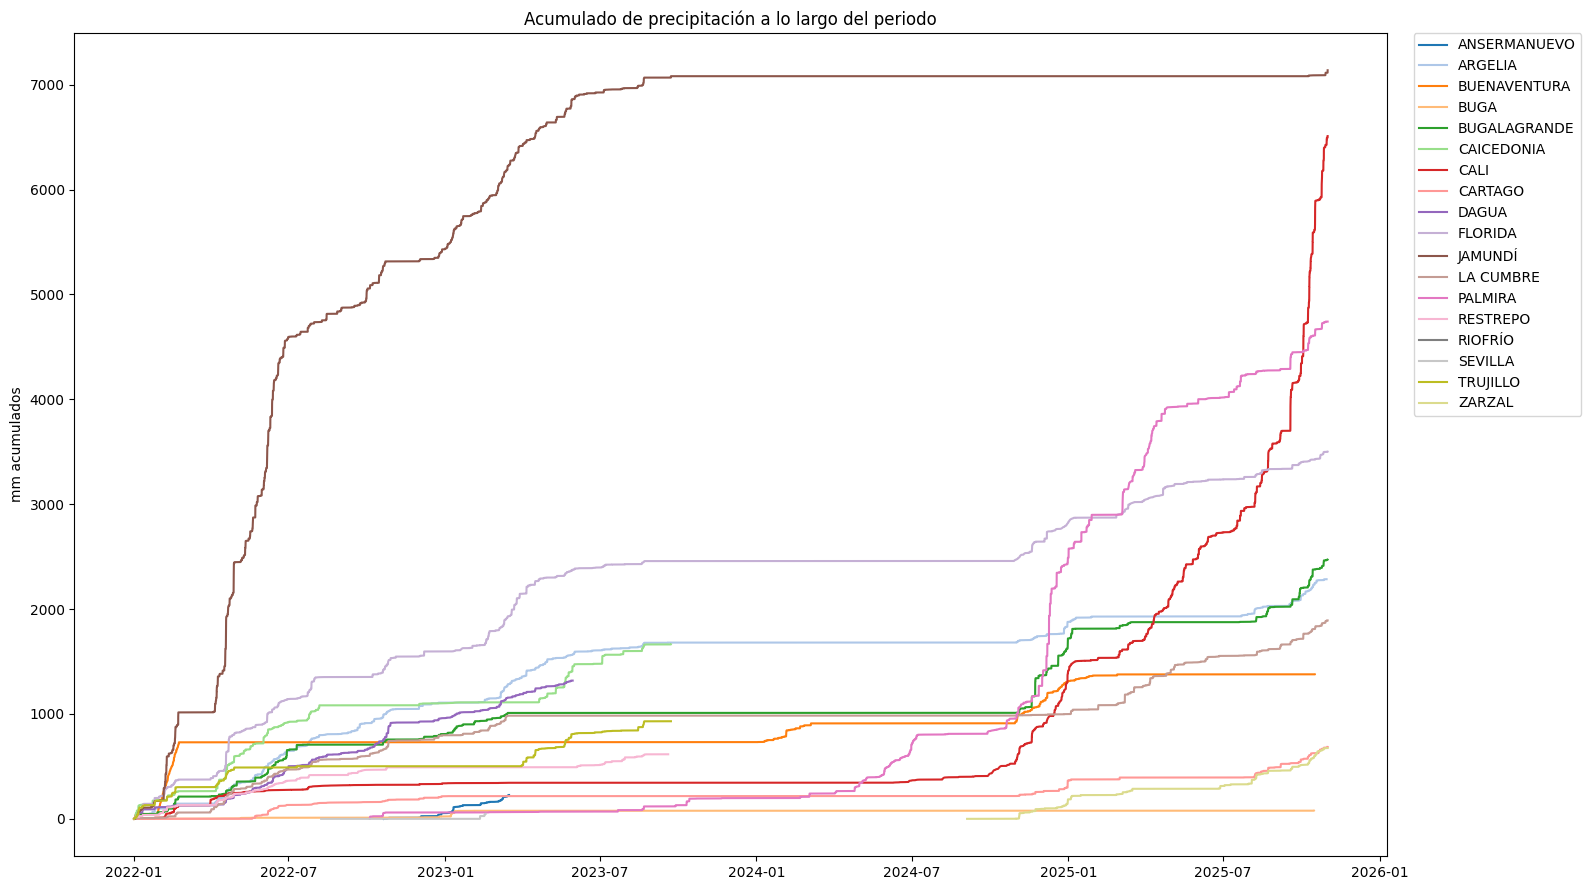

In [14]:
# ------------------------------
# 8. Cálculo de acumulados diarios (cumsum)
# ------------------------------
df_orden = df.sort_values('FechaObservacion')
df_orden['Acumulado'] = df_orden.groupby('Municipio')['ValorObservado'].cumsum()

fig, ax = plt.subplots(figsize=(16,9), dpi=100)          # 16:9 a 1600×900
cmap = plt.get_cmap('tab20')
for idx, (m, datos) in enumerate(df_orden.groupby('Municipio')):
    ax.plot(datos['FechaObservacion'], datos['Acumulado'],
            color=cmap(idx % 20), label=m, linewidth=1.5)
ax.set_ylabel('mm acumulados')
ax.set_title('Acumulado de precipitación a lo largo del periodo')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout(); plt.show()

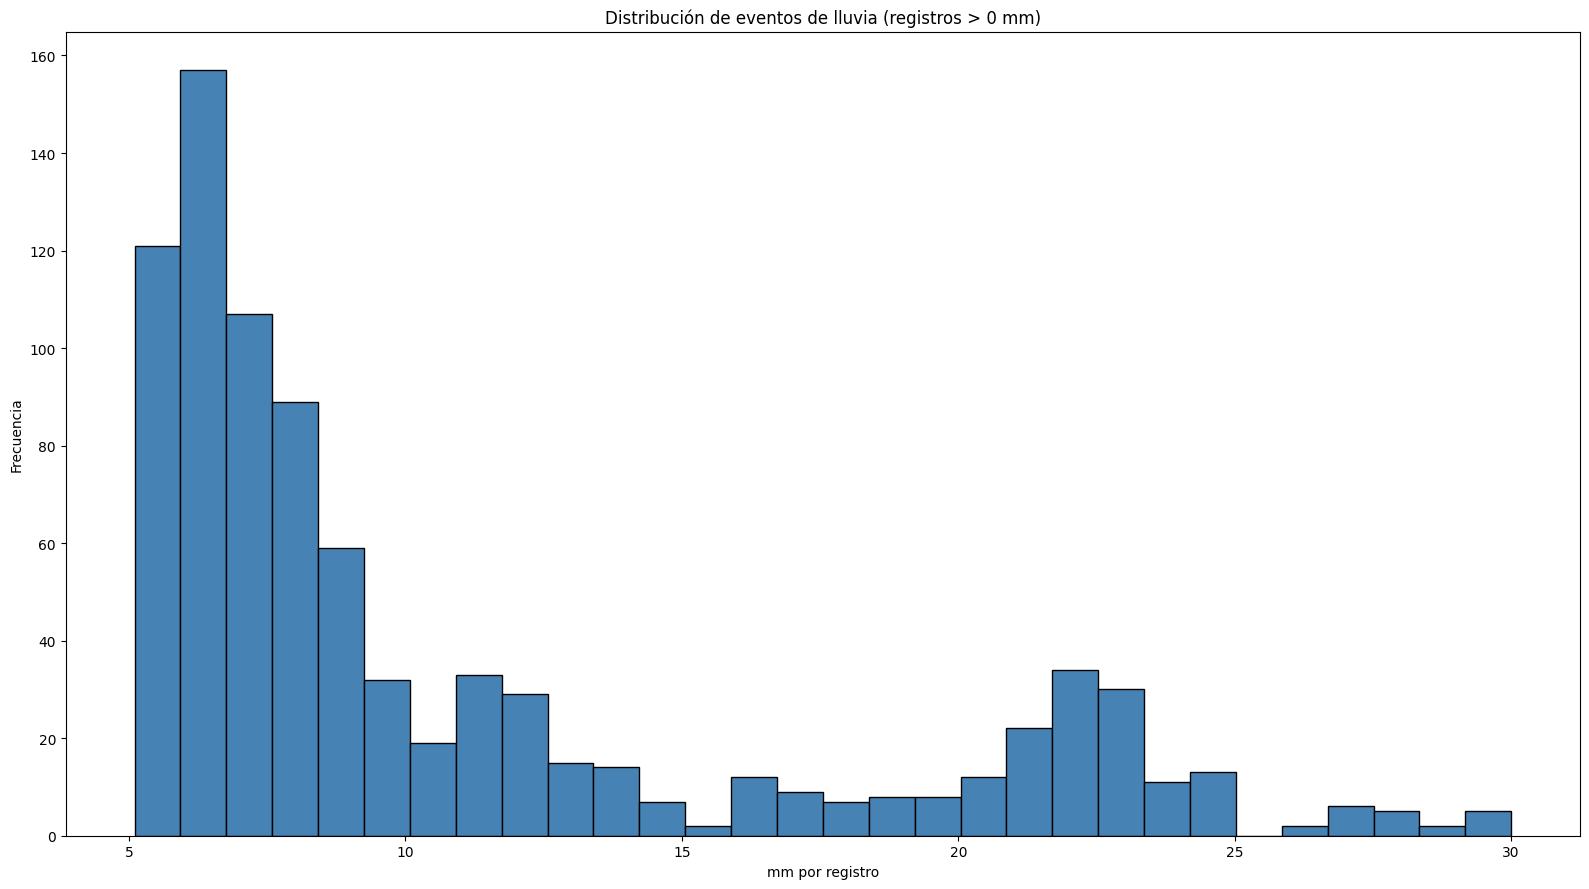

In [23]:
# ------------------------------
# 9. Histograma de intensidad de lluvia (registros > 5 mm)
# ------------------------------
lluvias = df['ValorObservado'][df['ValorObservado'] > 5]

fig, ax = plt.subplots(figsize=(16,9), dpi=100)
ax.hist(lluvias, bins=30, color='steelblue', edgecolor='k')
ax.set_xlabel('mm por registro')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de eventos de lluvia (registros > 0 mm)')
plt.tight_layout(); plt.show()

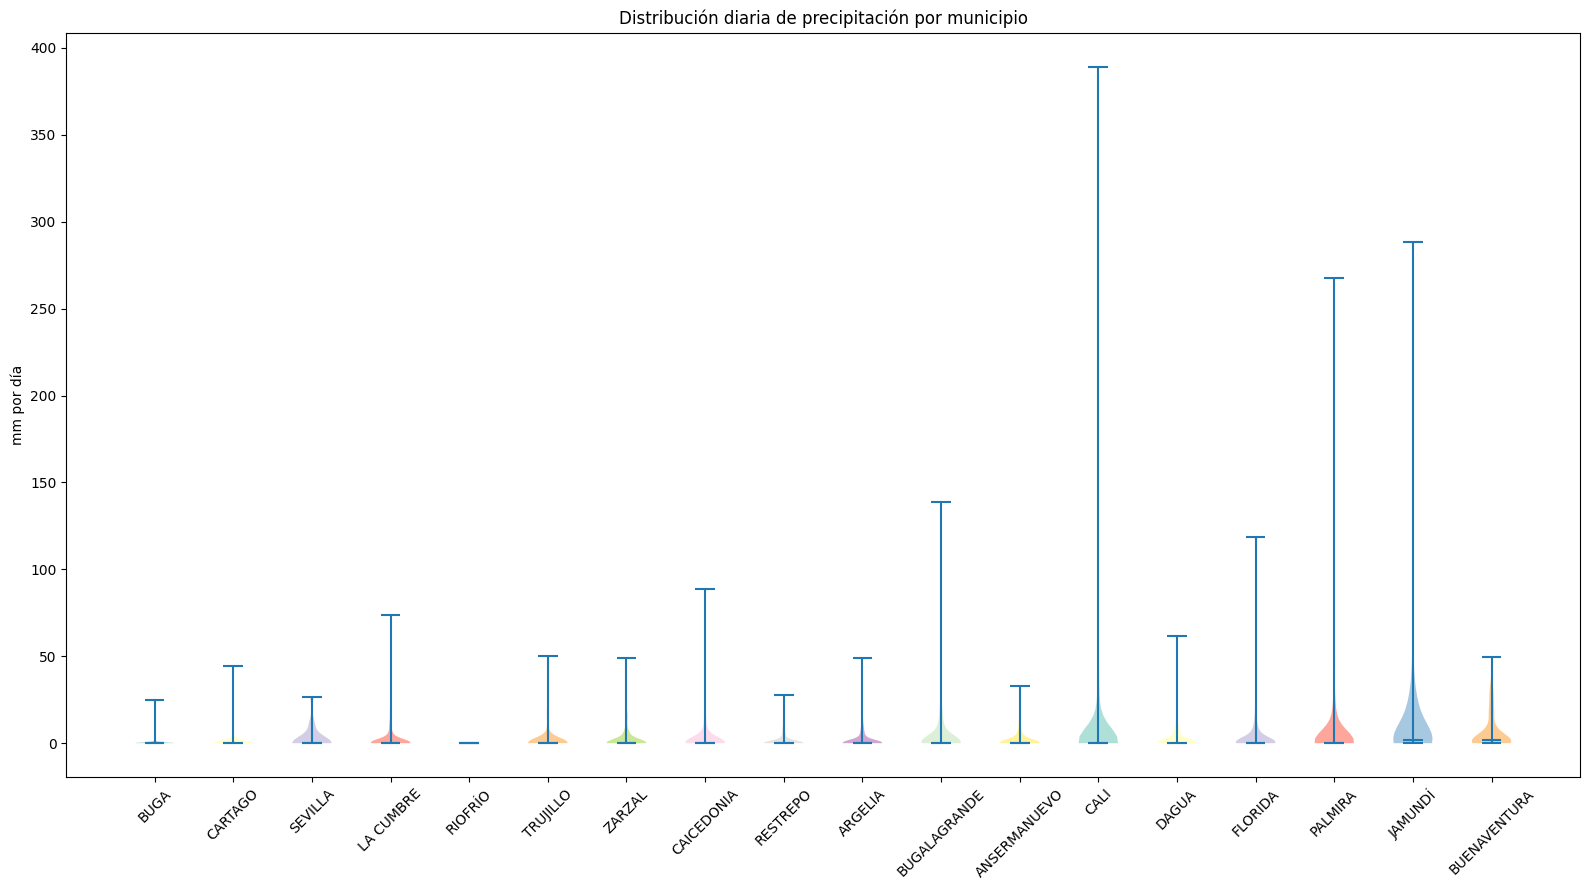

In [ ]:
# ------------------------------
# 10. Datos diarios por municipio
# ------------------------------
dias_mpio = df.groupby(['Municipio','Fecha'])['ValorObservado'].sum().reset_index()
orden = (dias_mpio.groupby('Municipio')['ValorObservado']
         .median().sort_values()).index

fig, ax = plt.subplots(figsize=(16,9), dpi=100)
violin = ax.violinplot([dias_mpio[dias_mpio['Municipio']==m]['ValorObservado']
                        for m in orden],
                       showmeans=False, showmedians=True, vert=True)
colors = plt.get_cmap('Set3').colors
for i, body in enumerate(violin['bodies']):
    body.set_facecolor(colors[i % len(colors)])
    body.set_alpha(0.7)

ax.set_xticks(range(1, len(orden)+1))
ax.set_xticklabels(orden, rotation=45)
ax.set_ylabel('mm por día')
ax.set_title('Distribución diaria de precipitación por municipio')
plt.tight_layout(); plt.show()


C:\Users\ASIS-INFORMATICA\AppData\Local\Temp\ipykernel_21068\2213771076.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dias_lluvia  = dias_mpio.groupby('Municipio').apply(lambda x: (x['ValorObservado']>0).sum())


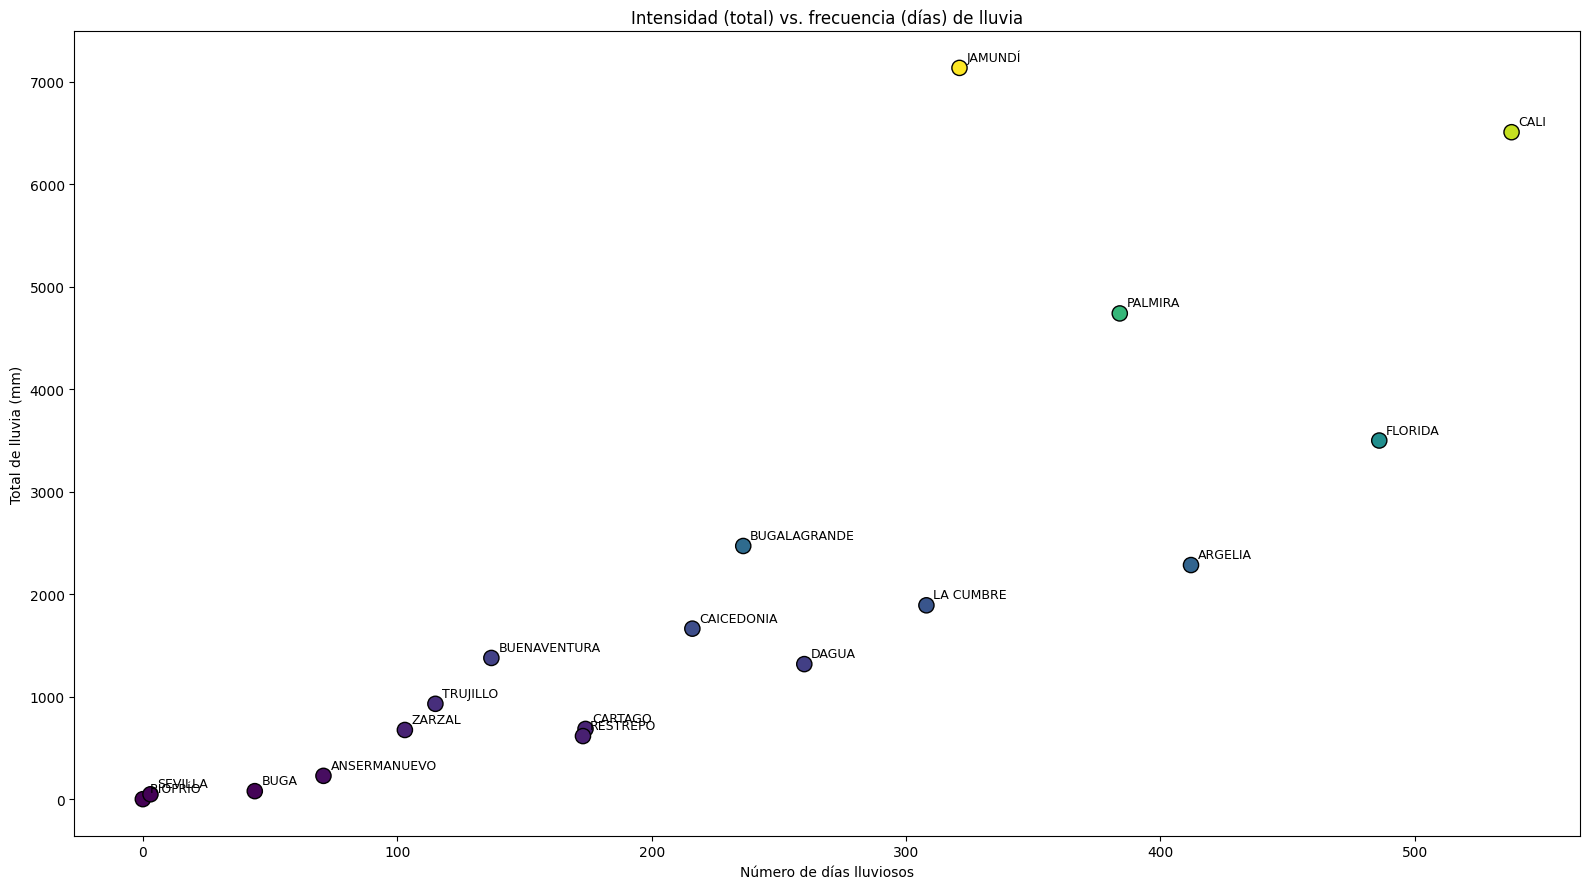

In [16]:
# ------------------------------
# 11. Intensidad vs frecuencia de lluvia
# ------------------------------
total_lluvia = df.groupby('Municipio')['ValorObservado'].sum()
dias_lluvia  = dias_mpio.groupby('Municipio').apply(lambda x: (x['ValorObservado']>0).sum())
metrics = pd.DataFrame({'Total_mm': total_lluvia, 'Dias_lluvia': dias_lluvia})

fig, ax = plt.subplots(figsize=(16,9), dpi=100)
scatter = ax.scatter(metrics['Dias_lluvia'], metrics['Total_mm'],
                     c=metrics['Total_mm'], cmap='viridis',
                     s=120, edgecolor='k')
for m, row in metrics.iterrows():
    ax.annotate(m, (row['Dias_lluvia'], row['Total_mm']),
                textcoords="offset points", xytext=(5,5), fontsize=9)
ax.set_xlabel('Número de días lluviosos')
ax.set_ylabel('Total de lluvia (mm)')
ax.set_title('Intensidad (total) vs. frecuencia (días) de lluvia')
plt.tight_layout(); plt.show()

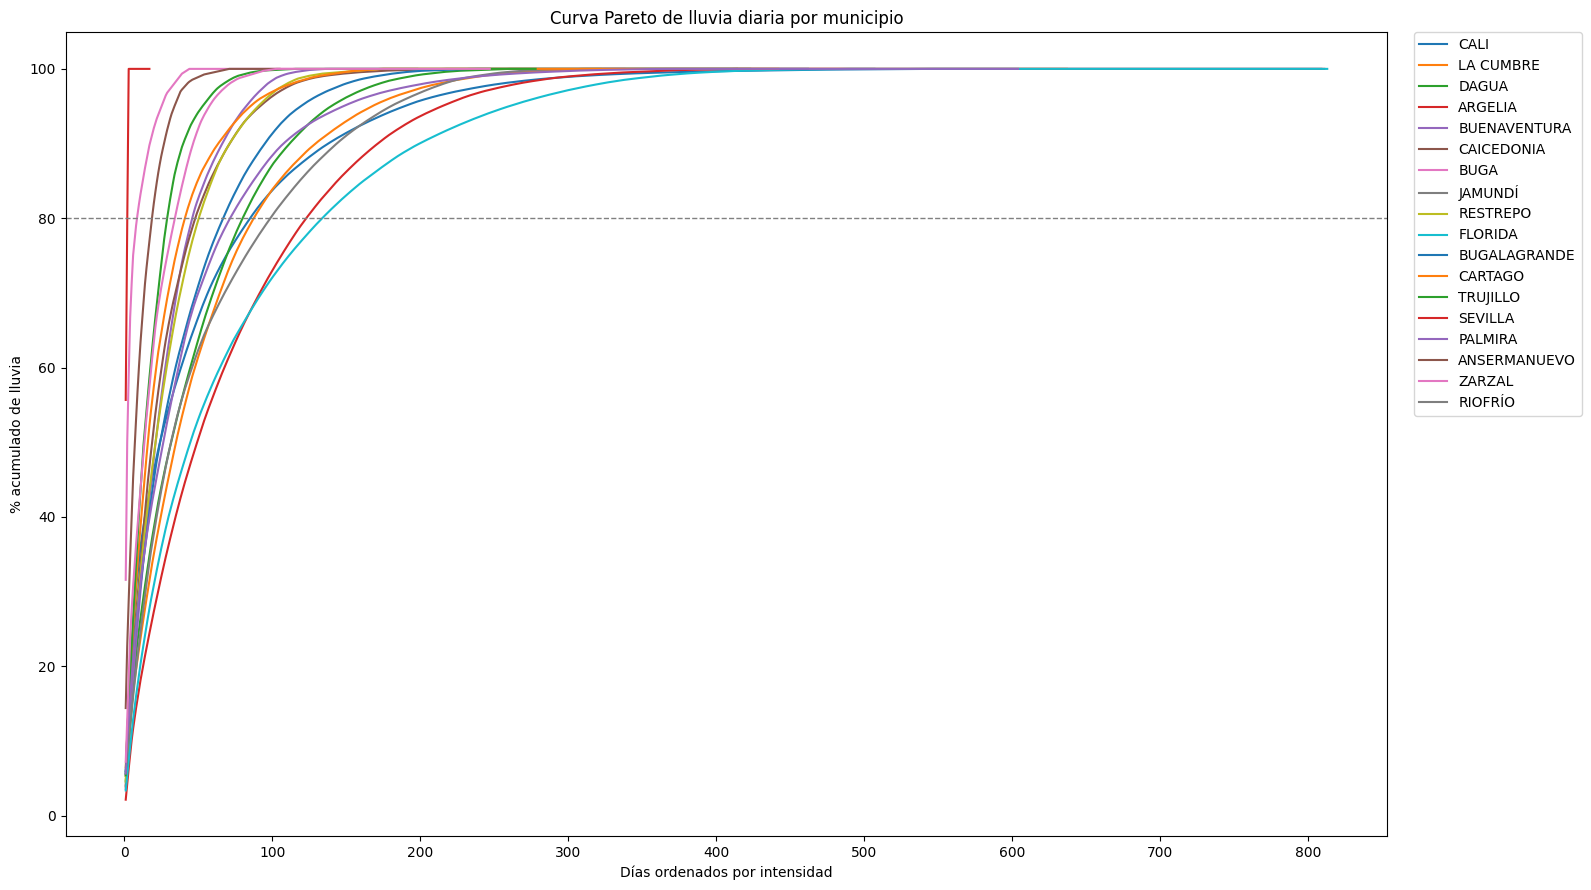

In [18]:
# ------------------------------
# 12. Curva Pareto de lluvia diaria
# ------------------------------

fig, ax = plt.subplots(figsize=(16,9), dpi=100)
colors = plt.get_cmap('tab10').colors

for idx, m in enumerate(df['Municipio'].unique()):
    lluvia_dias = dias_mpio[dias_mpio['Municipio']==m]['ValorObservado'].sort_values(ascending=False)
    pct_acum = lluvia_dias.cumsum() / lluvia_dias.sum() * 100
    ax.plot(range(1, len(pct_acum)+1), pct_acum,
            color=colors[idx % 10], label=m)

ax.axhline(80, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Días ordenados por intensidad')
ax.set_ylabel('% acumulado de lluvia')
ax.set_title('Curva Pareto de lluvia diaria por municipio')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout(); plt.show()


C:\Users\ASIS-INFORMATICA\AppData\Local\Temp\ipykernel_21068\1824690704.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['ValorObservado'].idxmax()])


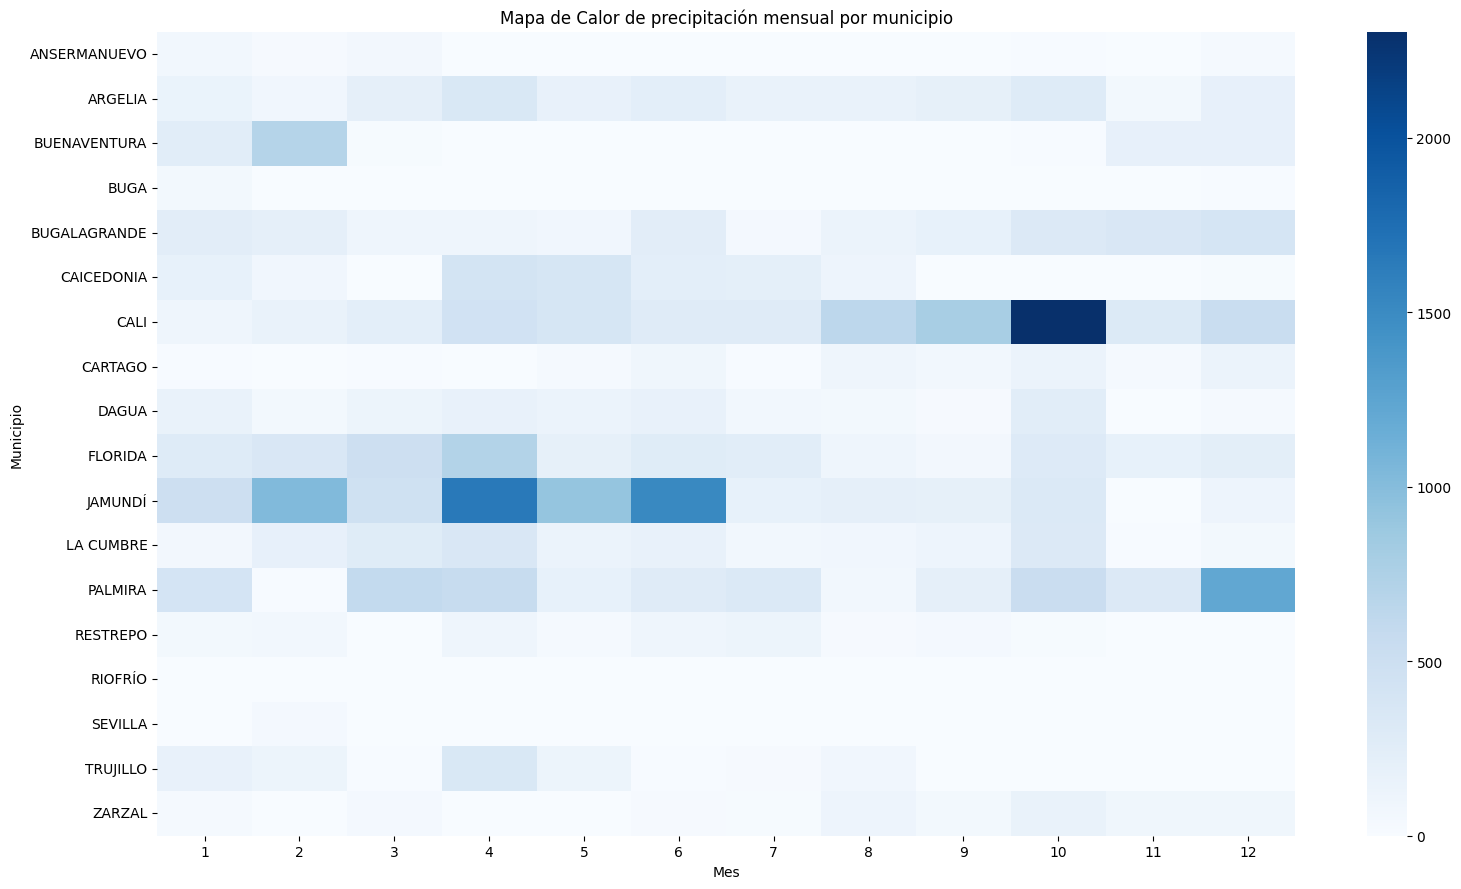

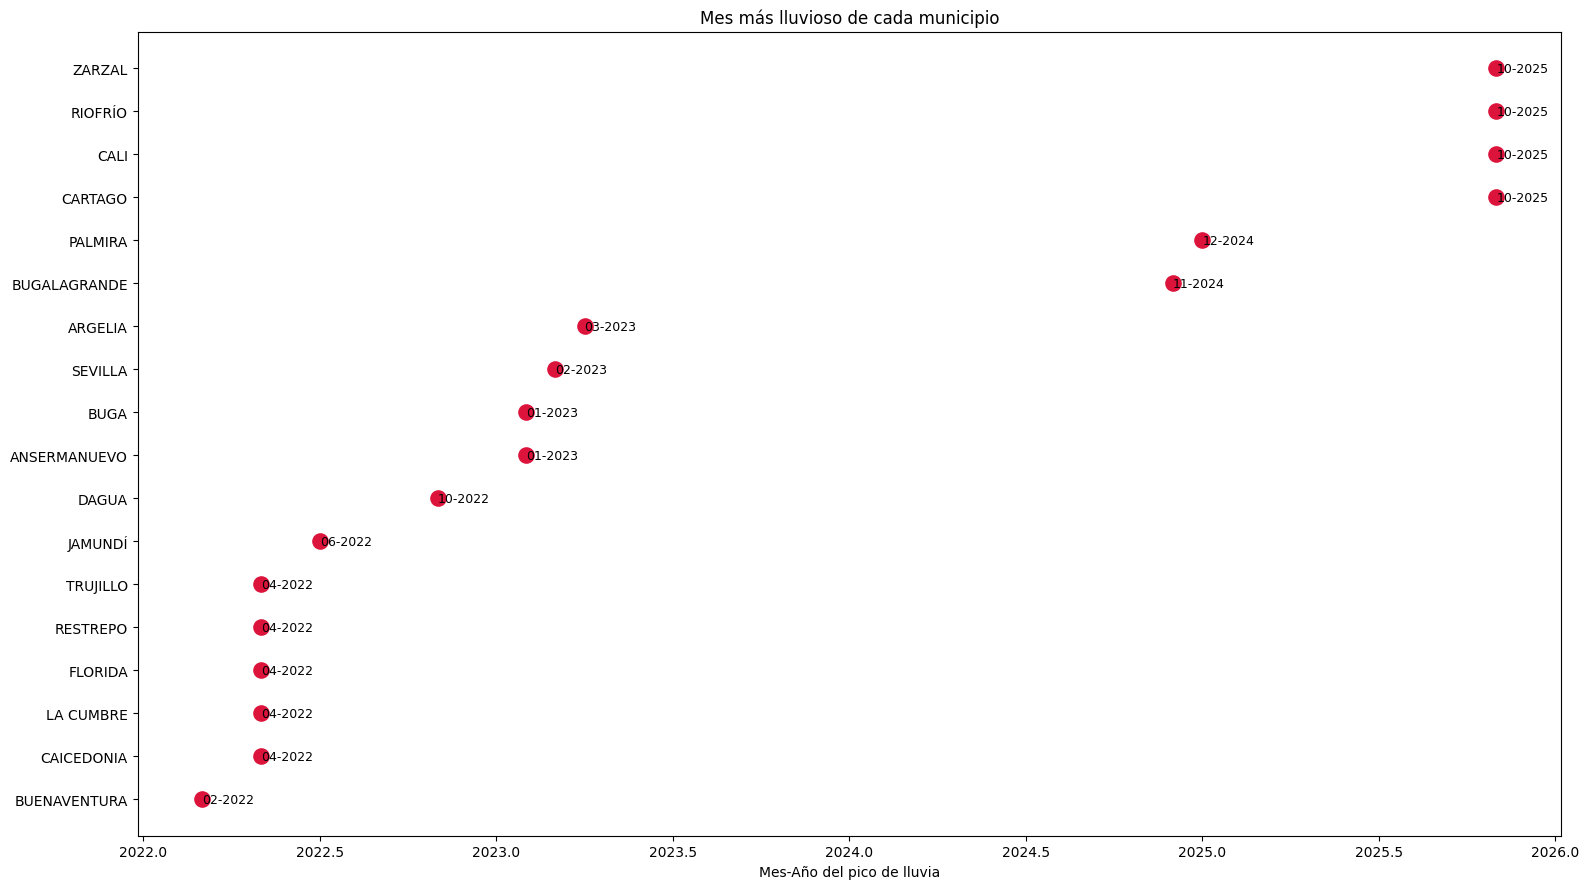

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegúrate de tener columnas Año, Mes, Municipio, ValorObservado
df['Mes'] = df['FechaObservacion'].dt.month
df['Año'] = df['FechaObservacion'].dt.year

# 1. Total mensual por municipio
mensual = (df.groupby(['Municipio', 'Año', 'Mes'])['ValorObservado']
             .sum()
             .reset_index())

# 2. Mes más lluvioso de cada municipio (sobre todo el período)
mes_top = (mensual.groupby('Municipio')
                   .apply(lambda x: x.loc[x['ValorObservado'].idxmax()])
                   .reset_index(drop=True))

# --- Heat-map de totales mensuales ----------------------------------
pivot = mensual.pivot_table(index='Municipio',
                            columns='Mes',
                            values='ValorObservado',
                            aggfunc='sum',
                            fill_value=0)

fig, ax = plt.subplots(figsize=(16,9), dpi=100)
sns.heatmap(pivot, cmap='Blues', ax=ax)
ax.set_title('Mapa de Calor de precipitación mensual por municipio')
ax.set_xlabel('Mes')
ax.set_ylabel('Municipio')
plt.tight_layout()
plt.show()

# --- Bump chart de mes máximo ---------------------------------------
# Convertir a número “Mes + Año/100” para ordenar de forma temporal
mes_top['MesOrd'] = mes_top['Año'] + mes_top['Mes']/12
mes_top = mes_top.sort_values('MesOrd')

fig, ax = plt.subplots(figsize=(16,9), dpi=100)
ax.scatter(mes_top['MesOrd'], mes_top['Municipio'],
           s=120, color='crimson', zorder=3)
for _, row in mes_top.iterrows():
    ax.text(row['MesOrd'], row['Municipio'],
            f"{int(row['Mes']):02d}-{row['Año']}",
            va='center', ha='left', fontsize=9)
ax.set_xlabel('Mes-Año del pico de lluvia')
ax.set_title('Mes más lluvioso de cada municipio')
plt.tight_layout()
plt.show()


# Hemos sabido acabar